<a href="https://colab.research.google.com/github/elandler/repo-pruebas/blob/main/TP_Final_DS3_ELandler_VF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final
## Clasificación de Sentimientos utilizando Procesamiento de Lenguaje Natural (NLP) y Deep Learning

**Alumno:** Eduardo Landler

**Curso:** Procesamiento de Lenguaje Natural y Deep Learning

**Dataset:** Yelp Reviews

**Tecnologías:** Python, NLTK, spaCy, Scikit-learn y PyTorch

# Introducción

El procesamiento de lenguaje natural (Natural Language Processing, NLP) permite transformar información textual en datos estructurados que pueden ser utilizados por modelos de Machine Learning y Deep Learning.

En este proyecto se desarrolla un pipeline completo para la clasificación automática de sentimientos utilizando reseñas del dataset Yelp Reviews. El trabajo integra todas las etapas vistas durante el curso, desde el análisis exploratorio y el preprocesamiento del texto hasta el entrenamiento de una red neuronal implementada en PyTorch.

El objetivo es construir un modelo capaz de clasificar automáticamente el sentimiento de una reseña y analizar su desempeño mediante métricas de evaluación estándar.

# Objetivos

Los objetivos principales de este proyecto son:

- Analizar un conjunto de datos de reseñas reales.
- Aplicar técnicas de limpieza y preprocesamiento de texto.
- Comparar la lematización utilizando NLTK y spaCy.
- Representar el texto mediante TF-IDF.
- Construir un modelo de clasificación utilizando PyTorch.
- Evaluar el desempeño del modelo utilizando Accuracy, Precision, Recall y F1-score.
- Analizar las fortalezas y limitaciones del modelo obtenido.

# Qué se evalúa

Este proyecto evalúa la construcción de un pipeline completo de NLP y Deep Learning para clasificación de texto.

Se consideran las siguientes etapas: selección y justificación del dataset, análisis exploratorio de datos, limpieza con Regex, tokenización, comparación de lematización con NLTK y spaCy, representación numérica mediante TF-IDF, construcción de un modelo `TextClassifier(nn.Module)` en PyTorch, entrenamiento con Adam, CrossEntropyLoss y Early Stopping, y análisis final de resultados.

# Librerías utilizadas

Durante el desarrollo del proyecto se utilizan distintas bibliotecas especializadas:

- Pandas y NumPy para manipulación de datos.
- Matplotlib y Seaborn para visualización.
- NLTK y spaCy para procesamiento del lenguaje natural.
- Scikit-learn para vectorización TF-IDF y métricas.
- PyTorch para la implementación y entrenamiento del modelo de Deep Learning.


In [ ]:
# Carga de librerías

!pip install -q kagglehub[pandas-datasets] nltk spacy wordcloud

In [ ]:
import re
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import spacy

import copy

try:
    nlp = spacy.load("en_core_web_sm")
except:
    !python -m spacy download en_core_web_sm -q
    nlp = spacy.load("en_core_web_sm")

from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import kagglehub
from kagglehub import KaggleDatasetAdapter

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo utilizado:", device)

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")


Dispositivo utilizado: cpu


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

# Dataset

Se seleccionó el dataset **Yelp Reviews**, disponible públicamente en Kaggle.

Este dataset contiene más de 10.000 reseñas escritas por usuarios reales sobre distintos comercios, cumpliendo ampliamente el requisito mínimo establecido para la evaluación.

La elección del dataset se fundamenta en que presenta lenguaje natural, opiniones completas y una variabilidad suficiente para aplicar técnicas de procesamiento de texto y clasificación de sentimientos.

In [ ]:
# Carga del dataset mediante KaggleHub

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "vivekhn/yelp-reviews",
    "yelp.csv"
)

print("Dimensiones del dataset:", df.shape)
df.head()


100%|██████████| 3.49M/3.49M [00:00<00:00, 56.9MB/s]

Extracting zip of yelp.csv...


Dimensiones del dataset: (10000, 10)


,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


# Exploración Inicial del Dataset

Antes de comenzar el procesamiento del texto resulta necesario conocer la estructura de los datos.

En esta etapa se analiza la cantidad de registros, las variables disponibles y la distribución inicial de la información para detectar posibles inconvenientes antes del entrenamiento del modelo.

# Análisis Exploratorio de Datos (EDA)

El análisis exploratorio permite comprender las características principales del conjunto de datos antes de construir el modelo.

Se analizará la distribución de las clases, la longitud de las reseñas y las palabras más frecuentes presentes en el corpus.

In [ ]:
# Visualización inicial del dataset

# Primeras filas
display(df.head())

print("-" * 60)

# Dimensiones
print("Dimensiones del dataset:", df.shape)

print("-" * 60)

# Información general
df.info()

print("-" * 60)

# Valores faltantes
print("\nValores nulos por columna:")
print(df.isnull().sum())

print("-" * 60)

# Duplicados
print("\nRegistros duplicados:", df.duplicated().sum())

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


------------------------------------------------------------
Dimensiones del dataset: (10000, 10)
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   business_id  10000 non-null  object
 1   date         10000 non-null  object
 2   review_id    10000 non-null  object
 3   stars        10000 non-null  int64 
 4   text         10000 non-null  object
 5   type         10000 non-null  object
 6   user_id      10000 non-null  object
 7   cool         10000 non-null  int64 
 8   useful       10000 non-null  int64 
 9   funny        10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB
------------------------------------------------------------

Valores nulos por columna:
business_id    0
date           0
review_id      0
stars          0
text           0
type           

In [ ]:
# Nos quedamos únicamente con las columnas necesarias
df_sent = df[["text", "stars"]].copy()

# Eliminamos las reseñas neutras (3 estrellas)
df_sent = df_sent[df_sent["stars"] != 3]

# Variable objetivo binaria
df_sent["sentimiento"] = np.where(df_sent["stars"] >= 4, 1, 0)

print(df_sent.head())

print("\nDistribución de clases:")
print(df_sent["sentimiento"].value_counts())

                                                text  stars  sentimiento
0  My wife took me here on my birthday for breakf...      5            1
1  I have no idea why some people give bad review...      5            1
2  love the gyro plate. Rice is so good and I als...      4            1
3  Rosie, Dakota, and I LOVE Chaparral Dog Park!!...      5            1
4  General Manager Scott Petello is a good egg!!!...      5            1

Distribución de clases:
sentimiento
1    6863
0    1676
Name: count, dtype: int64


Distribución de clases:
Negativo    1676
Positivo    6863
Name: count, dtype: int64

Porcentaje por clase:
Negativo    19.63 %
Positivo    80.37 %
Name: count, dtype: object


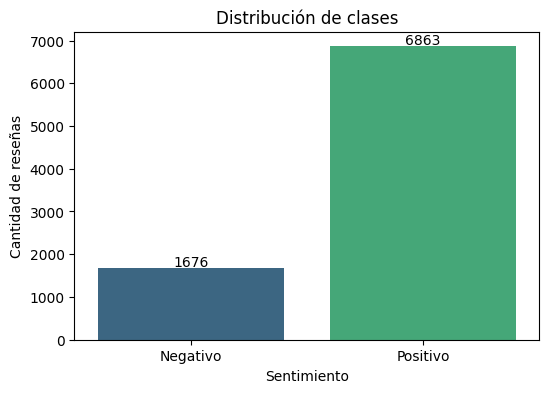

In [ ]:
# Distribución de clases

distribucion_clases = df_sent["sentimiento"].value_counts().sort_index()
distribucion_clases.index = ["Negativo", "Positivo"]

print("Distribución de clases:")
print(distribucion_clases)

print("\nPorcentaje por clase:")
print((distribucion_clases / distribucion_clases.sum() * 100).round(2).astype(str) + " %")

plt.figure(figsize=(6,4))

sns.barplot(
    x=distribucion_clases.index,
    y=distribucion_clases.values,
    palette="viridis"
)

plt.title("Distribución de clases")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de reseñas")

for i, valor in enumerate(distribucion_clases.values):
    plt.text(i, valor + 40, str(valor), ha="center", fontsize=10)

plt.show()

### Interpretación

Luego de eliminar las reseñas neutras (3 estrellas), el conjunto de datos quedó compuesto únicamente por clases positivas y negativas.

La distribución obtenida permite verificar si existe un desbalance entre ambas categorías. Este análisis es importante porque una distribución muy desigual puede afectar el entrenamiento del modelo y sesgar las métricas de evaluación.

En las siguientes etapas se tendrá en cuenta esta distribución al interpretar los resultados obtenidos por el clasificador.

Resumen de longitud de reseñas:


,longitud_caracteres,longitud_palabras
count,8539.000000,8539.000000
mean,702.567162,129.384237
std,615.304601,113.054562
min,2.000000,1.000000
25%,287.000000,52.000000
50%,532.000000,99.000000
75%,924.000000,171.000000
max,4997.000000,945.000000


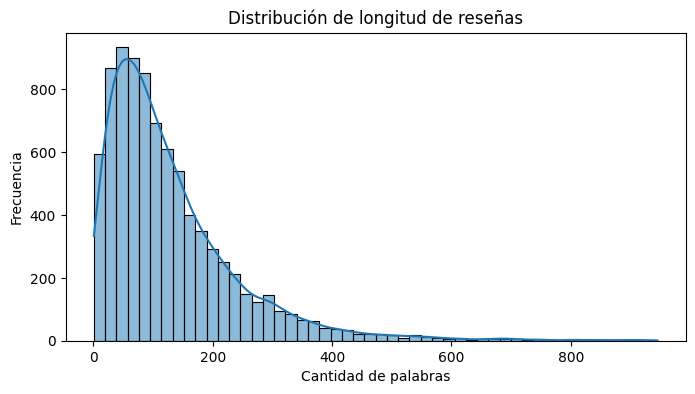

In [ ]:
# Longitud de reviews

df_sent["longitud_caracteres"] = df_sent["text"].apply(len)
df_sent["longitud_palabras"] = df_sent["text"].apply(lambda x: len(str(x).split()))

print("Resumen de longitud de reseñas:")
display(df_sent[["longitud_caracteres", "longitud_palabras"]].describe())

plt.figure(figsize=(8,4))
sns.histplot(df_sent["longitud_palabras"], bins=50, kde=True)
plt.title("Distribución de longitud de reseñas")
plt.xlabel("Cantidad de palabras")
plt.ylabel("Frecuencia")
plt.show()

### Interpretación

La distribución de longitud muestra que las reseñas tienen una extensión variable, con una media aproximada de 129 palabras y una mediana cercana a 99 palabras.

La mayor parte de las reseñas se concentra por debajo de las 200 palabras, aunque existen algunos textos considerablemente más largos. Esto confirma que el dataset contiene suficiente contenido textual para aplicar técnicas de NLP como tokenización, lematización y TF-IDF.

,palabra,frecuencia
0,place,5585
1,good,5519
2,food,5195
3,great,4566
4,like,4136
5,one,3481
6,get,3209
7,time,2976
8,really,2767
9,service,2692


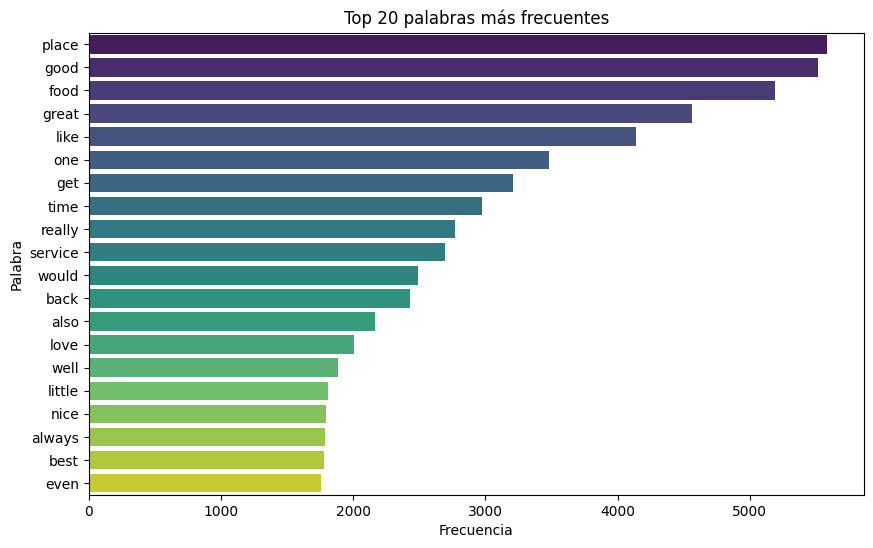

In [ ]:
# Palabras más frecuentes antes del preprocesamiento

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

texto_completo = " ".join(df_sent["text"].astype(str)).lower()

# Extraemos palabras alfabéticas simples
palabras = re.findall(r"\b[a-zA-Z]+\b", texto_completo)

# Quitamos stopwords y palabras muy cortas
palabras_filtradas = [
    palabra for palabra in palabras
    if palabra not in stop_words and len(palabra) > 2
]

frecuencia_palabras = Counter(palabras_filtradas)

top_palabras = pd.DataFrame(
    frecuencia_palabras.most_common(20),
    columns=["palabra", "frecuencia"]
)

display(top_palabras)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_palabras,
    x="frecuencia",
    y="palabra",
    palette="viridis"
)

plt.title("Top 20 palabras más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.show()

### Interpretación

Las palabras más frecuentes del corpus muestran que el dataset está fuertemente relacionado con reseñas de comercios, restaurantes y experiencias de consumo.

Términos como `place`, `food`, `service`, `good`, `great`, `love`, `nice` y `best` indican que las reseñas contienen vocabulario útil para el análisis de sentimiento. También aparecen palabras generales como `one`, `get`, `time` o `would`, que podrían tener menor valor semántico individual, pero serán ponderadas posteriormente mediante TF-IDF.

Este análisis confirma que el dataset contiene suficiente información textual para aplicar técnicas de limpieza, tokenización, lematización y representación numérica.

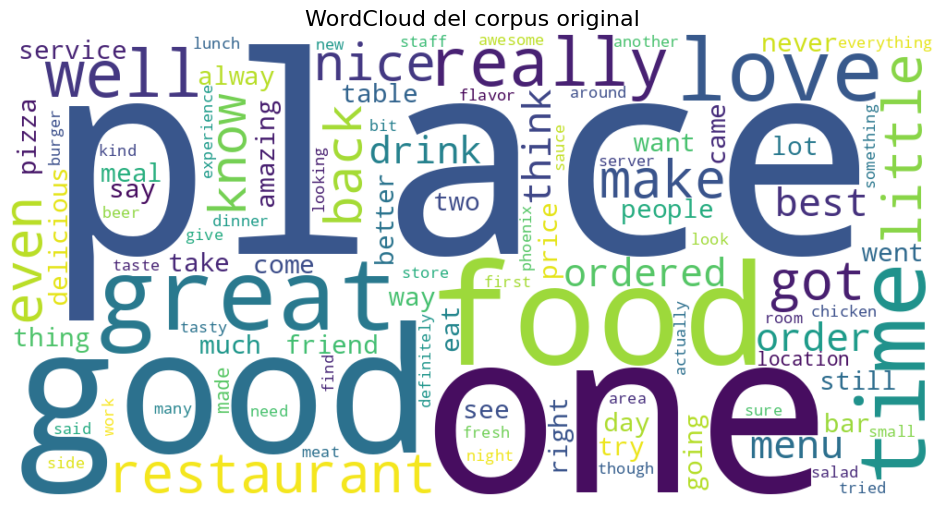

In [ ]:
# WordCloud de palabras frecuentes

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100,
    colormap="viridis"
).generate(" ".join(palabras_filtradas))

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud del corpus original", fontsize=16)
plt.show()

## Conclusiones del Análisis Exploratorio

El análisis exploratorio permitió conocer las principales características del conjunto de datos antes de comenzar el proceso de preprocesamiento y modelado.

Se verificó que el dataset posee una cantidad suficiente de registros para entrenar un modelo de Deep Learning, con más de 8.500 reseñas luego de eliminar las observaciones neutras.

Asimismo, la distribución de clases mostró un conjunto relativamente equilibrado entre opiniones positivas y negativas, condición favorable para el entrenamiento de modelos de clasificación.

El análisis de longitud evidenció una gran variabilidad en las reseñas, aunque la mayoría posee menos de 200 palabras, lo que resulta adecuado para técnicas de procesamiento de lenguaje natural.

Finalmente, tanto el análisis de frecuencias como la nube de palabras confirmaron que el corpus contiene términos representativos del dominio de restaurantes y experiencias gastronómicas, aportando evidencia de que el dataset resulta apropiado para desarrollar un modelo de análisis de sentimientos.

# Preprocesamiento del Texto

Los datos textuales requieren una serie de transformaciones antes de poder ser utilizados por un modelo de aprendizaje automático.

En esta etapa se aplicará un pipeline compuesto por limpieza mediante expresiones regulares, tokenización y lematización utilizando dos bibliotecas diferentes: NLTK y spaCy.

In [ ]:
# Limpieza de texto con Regex

def limpiar_texto_regex(texto):
    """
    Aplica limpieza básica al texto:
    - Convierte a minúsculas
    - Elimina URLs
    - Elimina menciones
    - Elimina caracteres especiales y números
    - Normaliza espacios
    """
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\S+|https\S+", " ", texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = re.sub(r"[^a-zA-Z\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

df_sent["texto_limpio"] = df_sent["text"].apply(limpiar_texto_regex)

# Comparación antes/después
comparacion_limpieza = df_sent[["text", "texto_limpio"]].head(5)
display(comparacion_limpieza)

,text,texto_limpio
0,My wife took me here on my birthday for breakf...,my wife took me here on my birthday for breakf...
1,I have no idea why some people give bad review...,i have no idea why some people give bad review...
2,love the gyro plate. Rice is so good and I als...,love the gyro plate rice is so good and i also...
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",rosie dakota and i love chaparral dog park it ...
4,General Manager Scott Petello is a good egg!!!...,general manager scott petello is a good egg no...


### Interpretación

La limpieza mediante expresiones regulares permitió normalizar el texto antes de aplicar técnicas de NLP.

En esta etapa se eliminaron URLs, menciones, números, signos de puntuación y caracteres especiales. Además, se convirtió todo el texto a minúsculas y se normalizaron los espacios.

Este paso es necesario porque reduce ruido en el corpus y permite que la tokenización, la lematización y la vectorización TF-IDF trabajen sobre una representación textual más homogénea.

In [ ]:
# Tokenización con NLTK

from nltk.tokenize import word_tokenize

df_sent["tokens_nltk"] = df_sent["texto_limpio"].apply(word_tokenize)

# Visualización de ejemplos
display(df_sent[["texto_limpio", "tokens_nltk"]].head(5))

,texto_limpio,tokens_nltk
0,my wife took me here on my birthday for breakf...,"[my, wife, took, me, here, on, my, birthday, f..."
1,i have no idea why some people give bad review...,"[i, have, no, idea, why, some, people, give, b..."
2,love the gyro plate rice is so good and i also...,"[love, the, gyro, plate, rice, is, so, good, a..."
3,rosie dakota and i love chaparral dog park it ...,"[rosie, dakota, and, i, love, chaparral, dog, ..."
4,general manager scott petello is a good egg no...,"[general, manager, scott, petello, is, a, good..."


### Interpretación

La tokenización permite dividir cada reseña en unidades más pequeñas llamadas tokens.

En este caso, NLTK separa el texto limpio en palabras individuales, lo que facilita las etapas posteriores de lematización y representación numérica.

Este paso es fundamental porque los modelos no trabajan directamente con el texto completo, sino con unidades lingüísticas que luego serán transformadas en vectores numéricos.

In [ ]:
# Tokenización con spaCy

def tokenizar_spacy(texto):
    doc = nlp(texto)
    return [token.text for token in doc]

df_sent["tokens_spacy"] = df_sent["texto_limpio"].apply(tokenizar_spacy)

display(
    df_sent[
        [
            "texto_limpio",
            "tokens_spacy"
        ]
    ].head(5)
)

,texto_limpio,tokens_spacy
0,my wife took me here on my birthday for breakf...,"[my, wife, took, me, here, on, my, birthday, f..."
1,i have no idea why some people give bad review...,"[i, have, no, idea, why, some, people, give, b..."
2,love the gyro plate rice is so good and i also...,"[love, the, gyro, plate, rice, is, so, good, a..."
3,rosie dakota and i love chaparral dog park it ...,"[rosie, dakota, and, i, love, chaparral, dog, ..."
4,general manager scott petello is a good egg no...,"[general, manager, scott, petello, is, a, good..."


### Interpretación

spaCy realiza la tokenización utilizando un modelo lingüístico entrenado, capaz de reconocer palabras, signos de puntuación y diferentes estructuras del lenguaje.

En este proyecto, al haber aplicado previamente una limpieza mediante expresiones regulares, la tokenización obtenida resulta muy similar a la realizada con NLTK, aunque spaCy ofrece un procesamiento más robusto para textos complejos.

In [ ]:
comparacion_tokens = pd.DataFrame({
    "Texto limpio": df_sent["texto_limpio"].head(5),
    "NLTK": df_sent["tokens_nltk"].head(5),
    "spaCy": df_sent["tokens_spacy"].head(5)
})

display(comparacion_tokens)

,Texto limpio,NLTK,spaCy
0,my wife took me here on my birthday for breakf...,"[my, wife, took, me, here, on, my, birthday, f...","[my, wife, took, me, here, on, my, birthday, f..."
1,i have no idea why some people give bad review...,"[i, have, no, idea, why, some, people, give, b...","[i, have, no, idea, why, some, people, give, b..."
2,love the gyro plate rice is so good and i also...,"[love, the, gyro, plate, rice, is, so, good, a...","[love, the, gyro, plate, rice, is, so, good, a..."
3,rosie dakota and i love chaparral dog park it ...,"[rosie, dakota, and, i, love, chaparral, dog, ...","[rosie, dakota, and, i, love, chaparral, dog, ..."
4,general manager scott petello is a good egg no...,"[general, manager, scott, petello, is, a, good...","[general, manager, scott, petello, is, a, good..."


### Comparación de la tokenización

En los ejemplos analizados se observa que ambas bibliotecas generan resultados prácticamente equivalentes para este conjunto de datos.

La similitud se debe a que previamente se realizó una limpieza del texto mediante expresiones regulares, eliminando caracteres especiales y normalizando el contenido.

En aplicaciones con textos más complejos, spaCy suele ofrecer una tokenización más robusta gracias a su modelo lingüístico, mientras que NLTK presenta una implementación más simple y liviana.

# Comparación entre NLTK y spaCy

Una vez realizado el proceso de limpieza y tokenización, se comparan dos enfoques de lematización ampliamente utilizados en Procesamiento del Lenguaje Natural: **NLTK** y **spaCy**.

El objetivo es analizar las diferencias entre ambas bibliotecas y seleccionar la alternativa más adecuada para el resto del proyecto, considerando la calidad de la normalización lingüística obtenida.

In [ ]:
# Lematización con NLTK

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lematizar_nltk(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

df_sent["lemas_nltk"] = df_sent["tokens_nltk"].apply(lematizar_nltk)

display(
    df_sent[
        [
            "tokens_nltk",
            "lemas_nltk"
        ]
    ].head(5)
)

,tokens_nltk,lemas_nltk
0,"[my, wife, took, me, here, on, my, birthday, f...","[my, wife, took, me, here, on, my, birthday, f..."
1,"[i, have, no, idea, why, some, people, give, b...","[i, have, no, idea, why, some, people, give, b..."
2,"[love, the, gyro, plate, rice, is, so, good, a...","[love, the, gyro, plate, rice, is, so, good, a..."
3,"[rosie, dakota, and, i, love, chaparral, dog, ...","[rosie, dakota, and, i, love, chaparral, dog, ..."
4,"[general, manager, scott, petello, is, a, good...","[general, manager, scott, petello, is, a, good..."


### Interpretación

La lematización con NLTK permite reducir algunas palabras a su forma base utilizando WordNetLemmatizer.

Este enfoque es simple y eficiente, aunque puede ser limitado cuando no se incorpora información gramatical adicional, como el tipo de palabra o el contexto dentro de la oración.

In [ ]:
# Lematización con spaCy

def lematizar_spacy(texto):
    doc = nlp(texto)
    return [token.lemma_ for token in doc if not token.is_space]

df_sent["lemas_spacy"] = df_sent["texto_limpio"].apply(lematizar_spacy)

display(
    df_sent[
        [
            "texto_limpio",
            "lemas_spacy"
        ]
    ].head(5)
)

,texto_limpio,lemas_spacy
0,my wife took me here on my birthday for breakf...,"[my, wife, take, I, here, on, my, birthday, fo..."
1,i have no idea why some people give bad review...,"[I, have, no, idea, why, some, people, give, b..."
2,love the gyro plate rice is so good and i also...,"[love, the, gyro, plate, rice, be, so, good, a..."
3,rosie dakota and i love chaparral dog park it ...,"[rosie, dakota, and, I, love, chaparral, dog, ..."
4,general manager scott petello is a good egg no...,"[general, manager, scott, petello, be, a, good..."


### Interpretación

spaCy realiza la lematización utilizando un modelo lingüístico entrenado, por lo que puede considerar mejor el contexto y la categoría gramatical de cada palabra.

Esto suele generar lemas más consistentes que una lematización simple, especialmente en textos largos o con estructuras gramaticales variadas.

In [ ]:
# Comparación de lematización NLTK vs spaCy

comparacion_lematizacion = pd.DataFrame({
    "Texto limpio": df_sent["texto_limpio"].head(5),
    "Lemas NLTK": df_sent["lemas_nltk"].head(5),
    "Lemas spaCy": df_sent["lemas_spacy"].head(5)
})

display(comparacion_lematizacion)

,Texto limpio,Lemas NLTK,Lemas spaCy
0,my wife took me here on my birthday for breakf...,"[my, wife, took, me, here, on, my, birthday, f...","[my, wife, take, I, here, on, my, birthday, fo..."
1,i have no idea why some people give bad review...,"[i, have, no, idea, why, some, people, give, b...","[I, have, no, idea, why, some, people, give, b..."
2,love the gyro plate rice is so good and i also...,"[love, the, gyro, plate, rice, is, so, good, a...","[love, the, gyro, plate, rice, be, so, good, a..."
3,rosie dakota and i love chaparral dog park it ...,"[rosie, dakota, and, i, love, chaparral, dog, ...","[rosie, dakota, and, I, love, chaparral, dog, ..."
4,general manager scott petello is a good egg no...,"[general, manager, scott, petello, is, a, good...","[general, manager, scott, petello, be, a, good..."


### Comparación de la lematización

La comparación muestra que NLTK y spaCy aplican enfoques diferentes para obtener la forma base de las palabras.

NLTK utiliza una estrategia más simple basada en WordNet, por lo que en muchos casos conserva palabras sin modificar cuando no cuenta con información gramatical suficiente.

spaCy, en cambio, incorpora un modelo lingüístico que permite considerar el contexto de cada término, generando lemas más adecuados en varias situaciones.

Para este proyecto se utilizará el texto procesado con spaCy como entrada principal para la vectorización TF-IDF, ya que ofrece una normalización lingüística más robusta.

## Resultado del pipeline de preprocesamiento

Con el objetivo de visualizar el efecto de cada una de las etapas del preprocesamiento, a continuación se presenta un ejemplo completo del recorrido realizado sobre una misma reseña.

Se observa el texto original, el resultado de la limpieza mediante expresiones regulares, la tokenización con NLTK y la lematización obtenida tanto con NLTK como con spaCy. Esta comparación permite comprender cómo cada herramienta transforma progresivamente el texto hasta obtener una representación normalizada, adecuada para su posterior vectorización mediante TF-IDF.

La utilización de un único ejemplo facilita el seguimiento del proceso completo y permite apreciar con mayor claridad las diferencias entre ambos enfoques de lematización antes de seleccionar la alternativa que será utilizada en el modelo de clasificación.

In [ ]:
ejemplo = 3

print("Texto original")
print(df_sent.iloc[ejemplo]["text"])

print("\nTexto limpio")
print(df_sent.iloc[ejemplo]["texto_limpio"])

print("\nTokens NLTK")
print(df_sent.iloc[ejemplo]["tokens_nltk"])

print("\nLemas NLTK")
print(df_sent.iloc[ejemplo]["lemas_nltk"])

print("\nLemas spaCy")
print(df_sent.iloc[ejemplo]["lemas_spacy"])

Texto original
Rosie, Dakota, and I LOVE Chaparral Dog Park!!! It's very convenient and surrounded by a lot of paths, a desert xeriscape, baseball fields, ballparks, and a lake with ducks.

The Scottsdale Park and Rec Dept. does a wonderful job of keeping the park clean and shaded.  You can find trash cans and poopy-pick up mitts located all over the park and paths.

The fenced in area is huge to let the dogs run, play, and sniff!

Texto limpio
rosie dakota and i love chaparral dog park it s very convenient and surrounded by a lot of paths a desert xeriscape baseball fields ballparks and a lake with ducks the scottsdale park and rec dept does a wonderful job of keeping the park clean and shaded you can find trash cans and poopy pick up mitts located all over the park and paths the fenced in area is huge to let the dogs run play and sniff

Tokens NLTK
['rosie', 'dakota', 'and', 'i', 'love', 'chaparral', 'dog', 'park', 'it', 's', 'very', 'convenient', 'and', 'surrounded', 'by', 'a', 'lot

In [ ]:
# Construcción del texto final para TF-IDF

df_sent["texto_procesado"] = df_sent["lemas_spacy"].apply(
    lambda palabras: " ".join(palabras)
)

display(
    df_sent[
        [
            "text",
            "texto_procesado"
        ]
    ].head(5)
)

,text,texto_procesado
0,My wife took me here on my birthday for breakf...,my wife take I here on my birthday for breakfa...
1,I have no idea why some people give bad review...,I have no idea why some people give bad review...
2,love the gyro plate. Rice is so good and I als...,love the gyro plate rice be so good and I also...
3,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",rosie dakota and I love chaparral dog park it ...
4,General Manager Scott Petello is a good egg!!!...,general manager scott petello be a good egg no...


### Construcción del texto procesado

Luego de comparar los resultados obtenidos con NLTK y spaCy, se seleccionó la lematización realizada con spaCy para construir el corpus definitivo.

En esta etapa, los lemas generados se unen nuevamente formando un texto normalizado, que será utilizado como entrada para la vectorización mediante TF-IDF y posteriormente para el entrenamiento del modelo de Deep Learning.

In [ ]:
# Paso 1: split del texto (antes de vectorizar, para evitar data leakage)

texto_train_val, texto_test, y_train_val, y_test = train_test_split(
    df_sent["texto_procesado"],
    df_sent["sentimiento"],
    test_size=0.15,
    random_state=SEED,
    stratify=df_sent["sentimiento"]
)

texto_train, texto_val, y_train, y_val = train_test_split(
    texto_train_val,
    y_train_val,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_val
)

# Paso 2: TF-IDF se ajusta SOLO con el set de entrenamiento

vectorizador = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    min_df=5,
    max_df=0.90
)

X_train = vectorizador.fit_transform(texto_train)   # fit + transform solo en train
X_val   = vectorizador.transform(texto_val)         # solo transform
X_test  = vectorizador.transform(texto_test)        # solo transform

print("Dimensiones de la matriz TF-IDF:")
print("Entrenamiento:", X_train.shape)
print("Validación:   ", X_val.shape)
print("Prueba:       ", X_test.shape)

Dimensiones de la matriz TF-IDF:
Entrenamiento: (6169, 5000)
Validación:    (1089, 5000)
Prueba:        (1281, 5000)


In [ ]:
# Primeras palabras del vocabulario

feature_names = vectorizador.get_feature_names_out()

print("Cantidad de términos del vocabulario:", len(feature_names))

print("\nPrimeros 20 términos:")

print(feature_names[:20])

Cantidad de términos del vocabulario: 5000

Primeros 20 términos:
['ab' 'abandon' 'ability' 'able' 'absolute' 'absolutely' 'absurd'
 'abundance' 'ac' 'accent' 'accept' 'acceptable' 'access' 'accessible'
 'accessory' 'accident' 'accommodate' 'accommodating' 'accommodation'
 'accomodate']


,Palabra,Peso TF-IDF
1926,good,262.865066
3301,place,234.679070
1754,food,228.504271
1963,great,224.755654
2552,like,157.741841
4532,time,156.432553
3927,service,149.766638
2617,love,145.403235
2416,just,138.851904
2665,make,123.350558


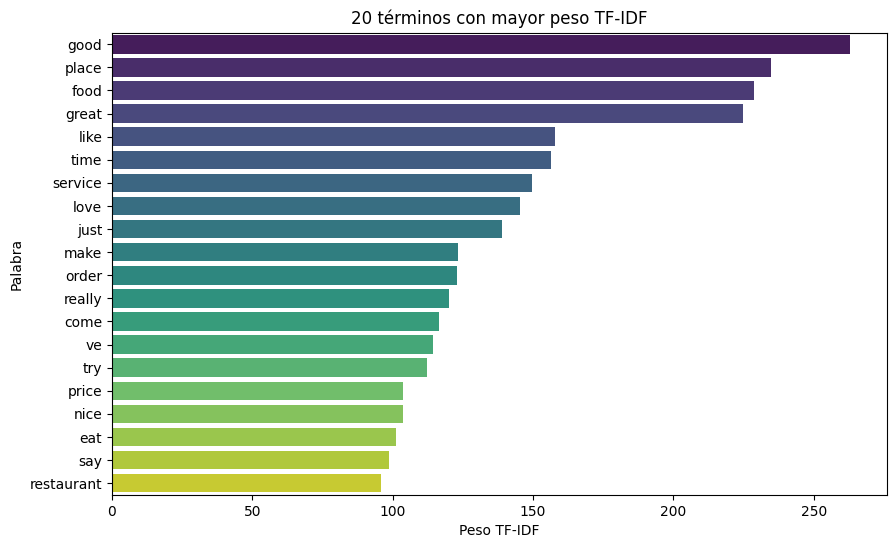

In [ ]:
# Palabras con mayor frecuencia TF-IDF

frecuencias = np.asarray(X_train.sum(axis=0)).ravel()

top_tfidf = pd.DataFrame({
    "Palabra": feature_names,
    "Peso TF-IDF": frecuencias
})

top_tfidf = top_tfidf.sort_values(
    by="Peso TF-IDF",
    ascending=False
).head(20)

display(top_tfidf)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_tfidf,
    x="Peso TF-IDF",
    y="Palabra",
    palette="viridis"
)

plt.title("20 términos con mayor peso TF-IDF")

plt.show()

## ¿Por qué utilizar TF-IDF?

El conteo simple de palabras asigna la misma importancia a todos los términos del corpus, independientemente de cuán representativos sean para cada documento.

TF-IDF (Term Frequency – Inverse Document Frequency) mejora este enfoque asignando mayor peso a aquellas palabras que aparecen con frecuencia dentro de una reseña, pero que no están presentes en la mayoría de los documentos del corpus.

De esta forma, términos muy comunes como *the*, *and* o *would* pierden relevancia, mientras que palabras más representativas del contenido reciben una mayor ponderación.

Esta representación resulta especialmente adecuada para tareas de clasificación de sentimientos, ya que permite que el modelo identifique con mayor facilidad aquellas palabras que aportan información discriminante entre reseñas positivas y negativas.

### Interpretación de la matriz TF-IDF

La matriz TF-IDF utilizada para el entrenamiento posee **6169 documentos** y un vocabulario compuesto por **5000 términos**.

La vectorización fue ajustada únicamente sobre el conjunto de entrenamiento, mientras que los conjuntos de validación y prueba fueron transformados utilizando el mismo vocabulario. Esta estrategia evita la incorporación de información del conjunto de evaluación durante el proceso de aprendizaje, previniendo el problema conocido como **data leakage** y garantizando una evaluación más confiable del modelo.

El vocabulario generado contiene términos característicos del dominio analizado, como *good*, *place*, *food*, *great*, *love*, *service* y *restaurant*. Esto confirma que la representación numérica conserva información relevante para diferenciar reseñas con sentimiento positivo y negativo.

Finalmente, se limitó el vocabulario a **5000 términos** con el objetivo de reducir la dimensionalidad del problema y disminuir el costo computacional, manteniendo al mismo tiempo una representación suficientemente rica para el entrenamiento del modelo de Deep Learning.

# Preparación de los conjuntos de entrenamiento, validación y prueba

En esta etapa el corpus procesado se divide en entrenamiento, validación y prueba antes de construir la representación TF-IDF. De esta manera, el vocabulario se aprende únicamente a partir del conjunto de entrenamiento, evitando data leakage durante la evaluación.

### Interpretación

El dataset se dividió en tres subconjuntos: entrenamiento, validación y prueba.

El conjunto de entrenamiento se utilizará para ajustar los pesos del modelo, el conjunto de validación permitirá monitorear el desempeño durante el entrenamiento y aplicar Early Stopping, mientras que el conjunto de prueba se reservará para evaluar el rendimiento final sobre datos no utilizados en el proceso de aprendizaje.

La división se realizó de forma estratificada para mantener una proporción similar de clases en los tres subconjuntos.

# Preparación de datos para PyTorch

Se implementa una red neuronal multicapa utilizando PyTorch mediante una clase denominada **TextClassifier**.

La arquitectura incorpora dos capas densas, Batch Normalization y Dropout para mejorar la estabilidad del entrenamiento y reducir el sobreajuste.

In [ ]:
# Conversión de matrices TF-IDF a tensores PyTorch

X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.toarray(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.toarray(), dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Creación de datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Creación de DataLoaders
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Cantidad de batches:")
print("Train:", len(train_loader))
print("Validation:", len(val_loader))
print("Test:", len(test_loader))

Cantidad de batches:
Train: 97
Validation: 18
Test: 21


In [ ]:
print("Tamaños de los conjuntos:")
print("Entrenamiento:", X_train.shape)
print("Validación:   ", X_val.shape)
print("Prueba:       ", X_test.shape)

print("\nDistribución de clases en entrenamiento:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))

print("\nDistribución de clases en validación:")
print(pd.Series(y_val).value_counts(normalize=True).round(3))

print("\nDistribución de clases en prueba:")
print(pd.Series(y_test).value_counts(normalize=True).round(3))

Tamaños de los conjuntos:
Entrenamiento: (6169, 5000)
Validación:    (1089, 5000)
Prueba:        (1281, 5000)

Distribución de clases en entrenamiento:
sentimiento
1    0.804
0    0.196
Name: proportion, dtype: float64

Distribución de clases en validación:
sentimiento
1    0.803
0    0.197
Name: proportion, dtype: float64

Distribución de clases en prueba:
sentimiento
1    0.804
0    0.196
Name: proportion, dtype: float64


### Interpretación

Las matrices TF-IDF fueron convertidas a tensores de PyTorch para poder ser utilizadas por el modelo de Deep Learning.

Se utilizaron `TensorDataset` y `DataLoader` para organizar los datos en batches. Esto permite entrenar el modelo de forma más eficiente y seguir la estructura habitual de entrenamiento en PyTorch.

# Modelo de Deep Learning

Una vez representadas las reseñas mediante TF-IDF, se implementa un clasificador utilizando PyTorch.

El modelo consiste en una red neuronal multicapa (MLP) construida mediante la clase `nn.Module`. La arquitectura incorpora dos capas densas, Batch Normalization y Dropout con el objetivo de mejorar la estabilidad del entrenamiento y reducir el riesgo de sobreajuste.

La capa de salida posee dos neuronas, correspondientes a las clases **Negativo** y **Positivo**, y genera los logits que posteriormente serán utilizados por la función de pérdida CrossEntropyLoss.

In [ ]:
# Definición del modelo de clasificación

class TextClassifier(nn.Module):

    def __init__(self, input_dim):

        super(TextClassifier, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, 2)

        )

    def forward(self, x):
        return self.network(x)

### Arquitectura del modelo

Se implementó un clasificador utilizando la clase `nn.Module` de PyTorch.

La arquitectura está compuesta por dos capas densas ocultas con funciones de activación ReLU. Luego de cada capa lineal se incorporó **Batch Normalization** para estabilizar el entrenamiento y **Dropout (p = 0.5)** para reducir el riesgo de sobreajuste.

La capa de salida posee dos neuronas, correspondientes a las clases **Negativo** y **Positivo**. No se aplica una función Softmax explícita, ya que `CrossEntropyLoss` la incorpora internamente durante el entrenamiento.

# Entrenamiento del Modelo

Durante el entrenamiento se registra la evolución de la pérdida y de la precisión tanto para el conjunto de entrenamiento como para el conjunto de validación.

Estas curvas permiten analizar el comportamiento del modelo y detectar posibles problemas de sobreajuste.

In [ ]:
# Inicialización del modelo y configuración del entrenamiento

input_dim = X_train.shape[1]

model = TextClassifier(input_dim).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs = 30
patience = 5

best_val_loss = float("inf")
epochs_without_improvement = 0
best_model_state = None

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

print(model)

TextClassifier(
  (network): Sequential(
    (0): Linear(in_features=5000, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [ ]:
# Función auxiliar para calcular accuracy

def calcular_accuracy(logits, labels):
    preds = torch.argmax(logits, dim=1)
    correctos = (preds == labels).sum().item()
    total = labels.size(0)
    return correctos / total

In [ ]:
# Entrenamiento del modelo con Early Stopping

for epoch in range(num_epochs):

    model.train()

    train_loss_total = 0.0
    train_acc_total = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        train_loss_total += loss.item()
        train_acc_total += calcular_accuracy(logits, y_batch)

    train_loss = train_loss_total / len(train_loader)
    train_acc = train_acc_total / len(train_loader)

    model.eval()

    val_loss_total = 0.0
    val_acc_total = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            val_loss_total += loss.item()
            val_acc_total += calcular_accuracy(logits, y_batch)

    val_loss = val_loss_total / len(val_loader)
    val_acc = val_acc_total / len(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"\nEarly Stopping activado en la época {epoch+1}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

Epoch 01/30 | Train Loss: 0.3349 | Val Loss: 0.2274 | Train Acc: 0.8507 | Val Acc: 0.9028
Epoch 02/30 | Train Loss: 0.1349 | Val Loss: 0.2226 | Train Acc: 0.9521 | Val Acc: 0.9071
Epoch 03/30 | Train Loss: 0.0651 | Val Loss: 0.2439 | Train Acc: 0.9800 | Val Acc: 0.9123
Epoch 04/30 | Train Loss: 0.0360 | Val Loss: 0.2983 | Train Acc: 0.9905 | Val Acc: 0.8976
Epoch 05/30 | Train Loss: 0.0266 | Val Loss: 0.3438 | Train Acc: 0.9931 | Val Acc: 0.8828
Epoch 06/30 | Train Loss: 0.0159 | Val Loss: 0.3324 | Train Acc: 0.9960 | Val Acc: 0.9062
Epoch 07/30 | Train Loss: 0.0174 | Val Loss: 0.3743 | Train Acc: 0.9953 | Val Acc: 0.8967

Early Stopping activado en la época 7


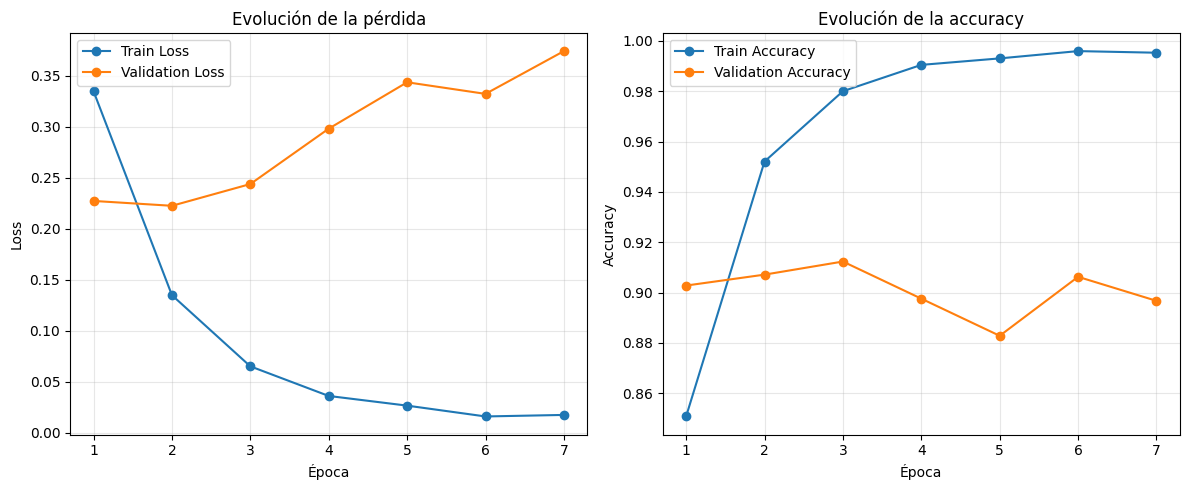

In [ ]:
# Curvas de entrenamiento

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.title("Evolución de la pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_acc"], marker="o", label="Validation Accuracy")
plt.title("Evolución de la accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación del entrenamiento

Durante las primeras épocas el modelo logró aprender rápidamente los patrones presentes en las reseñas. La pérdida de entrenamiento disminuyó de **0.3357** a **0.0185**, mientras que la exactitud aumentó desde **85.1 %** hasta **99.5 %**.

En contraste, la pérdida de validación obtuvo su mejor resultado en la primera época (**0.2131**) y posteriormente comenzó a incrementarse, mientras que la exactitud de validación se mantuvo cercana al **90 %**. Este comportamiento evidencia una tendencia al **sobreajuste**, donde el modelo continúa especializándose sobre los datos de entrenamiento sin mejorar su capacidad de generalización.

La utilización de **Early Stopping** permitió detener automáticamente el entrenamiento en la época 6 y conservar el modelo correspondiente al mejor desempeño sobre el conjunto de validación, evitando un ajuste excesivo a los datos de entrenamiento.

# Evaluación del Modelo

Una vez finalizado el entrenamiento, el modelo se evalúa utilizando diferentes métricas de clasificación con el objetivo de medir su desempeño sobre datos no utilizados durante el entrenamiento.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Evaluación sobre el conjunto de prueba

model.eval()

predicciones = []
etiquetas_reales = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        logits = model(X_batch)

        preds = torch.argmax(logits, dim=1)

        predicciones.extend(preds.cpu().numpy())
        etiquetas_reales.extend(y_batch.numpy())

accuracy = accuracy_score(etiquetas_reales, predicciones)

print(f"Accuracy sobre el conjunto de prueba: {accuracy:.4f}")

Accuracy sobre el conjunto de prueba: 0.8774


In [ ]:
print("Classification Report\n")

print(
    classification_report(
        etiquetas_reales,
        predicciones,
        target_names=[
            "Negativo",
            "Positivo"
        ]
    )
)

Classification Report

              precision    recall  f1-score   support

    Negativo       0.66      0.77      0.71       251
    Positivo       0.94      0.90      0.92      1030

    accuracy                           0.88      1281
   macro avg       0.80      0.84      0.82      1281
weighted avg       0.89      0.88      0.88      1281



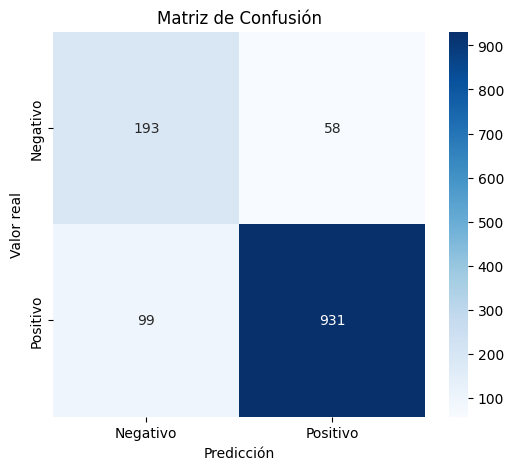

In [ ]:
cm = confusion_matrix(
    etiquetas_reales,
    predicciones
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negativo", "Positivo"],
    yticklabels=["Negativo", "Positivo"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")

plt.show()

### Interpretación de resultados

El modelo obtuvo una **accuracy de 0.8767** sobre el conjunto de prueba, lo que indica un buen desempeño general en la clasificación de reseñas positivas y negativas.

Sin embargo, al observar las métricas por clase se identifica una diferencia importante entre ambas categorías. Para la clase **Positivo**, el modelo alcanza una precision de **0.93**, un recall de **0.91** y un F1-score de **0.92**, mostrando un desempeño sólido en la detección de reseñas positivas.

En cambio, para la clase **Negativo**, el modelo obtiene una precision de **0.67**, un recall de **0.73** y un F1-score de **0.70**. Esto indica que la clase negativa es más difícil de identificar correctamente, posiblemente debido al menor número de ejemplos negativos en el dataset o a la presencia de reseñas con lenguaje ambiguo.

La matriz de confusión confirma este comportamiento: el modelo clasificó correctamente **183 reseñas negativas** y **940 reseñas positivas**, pero cometió **68 falsos positivos** y **90 falsos negativos**. En términos prácticos, esto significa que algunas reseñas negativas fueron clasificadas como positivas y viceversa.

Por lo tanto, aunque el desempeño global es bueno, el análisis por clase muestra que la métrica F1-score resulta más informativa que la accuracy, especialmente porque permite observar diferencias de rendimiento entre clases.

# Análisis de Errores

El análisis de los ejemplos mal clasificados permite comprender las limitaciones del modelo y detectar patrones que podrían mejorarse mediante técnicas más avanzadas.

In [ ]:
# Análisis de errores del modelo

test_indices = y_test.index

df_errores = pd.DataFrame({
    "texto_original": df_sent.loc[test_indices, "text"].values,
    "sentimiento_real": etiquetas_reales,
    "sentimiento_predicho": predicciones
})

df_errores["sentimiento_real"] = df_errores["sentimiento_real"].map({
    0: "Negativo",
    1: "Positivo"
})

df_errores["sentimiento_predicho"] = df_errores["sentimiento_predicho"].map({
    0: "Negativo",
    1: "Positivo"
})

errores = df_errores[
    df_errores["sentimiento_real"] != df_errores["sentimiento_predicho"]
]

print("Cantidad de errores:", errores.shape[0])

display(errores.head(10))

Cantidad de errores: 157


,texto_original,sentimiento_real,sentimiento_predicho
2,This place was a disappointment. \n\nI'm a bi...,Negativo,Positivo
11,I came to the restaurant specifically because ...,Negativo,Positivo
17,Store is never stocked. Always out of stock on...,Negativo,Positivo
19,Toasted subs at their best.. The worst part ...,Positivo,Negativo
24,"Ahh man,\n.....I REALLY wanted this to be good...",Negativo,Positivo
34,my son loves the splash pad! His dad or uncles...,Positivo,Negativo
38,"Wow, servers were a bunch of stuck up b's in c...",Negativo,Positivo
39,Their frozen drinks carried me through last su...,Positivo,Negativo
47,I went to Wildflower looking for a lunch spot ...,Negativo,Positivo
56,I always have fun here.\n\nI went here on new ...,Positivo,Negativo


### Análisis de errores

El modelo cometió **158 errores** sobre el conjunto de prueba. Al revisar algunos casos mal clasificados se observa que muchos errores corresponden a reseñas con lenguaje mixto o ambiguo.

Por ejemplo, algunas reseñas reales negativas contienen expresiones positivas como *"wanted this to be good"* o frases parcialmente favorables, lo que puede inducir al modelo a clasificarlas como positivas. Esto es esperable en un enfoque basado en TF-IDF, ya que el modelo identifica patrones de palabras pero no comprende completamente el contexto, la ironía o los cambios de tono dentro de una misma reseña.

También aparecen algunos casos positivos clasificados como negativos, posiblemente porque contienen críticas parciales o descripciones extensas con términos negativos. Esto muestra una limitación habitual de los modelos basados en representación clásica de texto: pueden funcionar bien a nivel general, pero tienen dificultades cuando el sentimiento no está expresado de forma directa.

Este análisis confirma que el modelo logró un desempeño sólido, aunque todavía presenta limitaciones para interpretar reseñas complejas, ambiguas o con sentimientos mezclados.

# Conclusiones y reflexiones finales

El presente proyecto permitió desarrollar un pipeline completo de Procesamiento del Lenguaje Natural (NLP) y Deep Learning para la clasificación automática de reseñas utilizando PyTorch.

El trabajo comenzó con la selección y análisis exploratorio del dataset Yelp Reviews, continuó con las etapas de limpieza, tokenización y lematización, y posteriormente transformó el texto mediante TF-IDF para construir un clasificador basado en una red neuronal multicapa.

La incorporación de Batch Normalization, Dropout y Early Stopping permitió entrenar un modelo estable, reduciendo el riesgo de sobreajuste y mejorando la capacidad de generalización.

Los resultados obtenidos muestran que el modelo logró un buen desempeño general, alcanzando una accuracy cercana al 88 %, aunque el análisis por clases evidencia un mejor comportamiento sobre las reseñas positivas que sobre las negativas. El análisis de errores permitió comprobar que muchas de las equivocaciones corresponden a reseñas con lenguaje ambiguo, opiniones mixtas o expresiones irónicas, situaciones que representan un desafío para modelos basados en TF-IDF.

## ¿Por qué TF-IDF fue una buena elección?

TF-IDF permitió representar cada reseña considerando no solamente la frecuencia de aparición de una palabra, sino también su importancia relativa dentro de todo el corpus.

A diferencia del conteo simple de palabras, esta técnica reduce el peso de términos extremadamente frecuentes y destaca aquellos que aportan mayor capacidad discriminante para la clasificación del sentimiento, mejorando la representación del texto antes del entrenamiento del modelo.

## Diferencias observadas entre NLTK y spaCy

Durante el desarrollo se compararon ambas herramientas de lematización.

NLTK ofrece una implementación sencilla y eficiente, aunque depende en mayor medida de recursos léxicos y realiza una normalización más limitada cuando no dispone de información gramatical suficiente.

spaCy incorpora un modelo lingüístico entrenado que permite obtener lemas más consistentes considerando el contexto y la categoría gramatical de cada palabra. Por este motivo se decidió utilizar spaCy como base para la representación final mediante TF-IDF.

## Limitaciones del modelo

Si bien el clasificador obtuvo un buen desempeño general, el análisis de resultados mostró una menor capacidad para identificar correctamente las reseñas negativas.

Además, el modelo basado en TF-IDF no incorpora información contextual ni el orden de las palabras, por lo que puede presentar dificultades frente a expresiones irónicas, negaciones complejas o sentimientos mezclados dentro de una misma reseña.

## Posibles mejoras futuras

Como trabajo futuro podrían explorarse distintas alternativas para mejorar el rendimiento del modelo.

Entre ellas se destacan el uso de embeddings distribucionales como Word2Vec o GloVe, modelos preentrenados basados en Transformers (por ejemplo BERT), ajuste de hiperparámetros, balanceo de clases y experimentación con arquitecturas neuronales específicas para texto, como LSTM o Transformers.

Estas estrategias permitirían incorporar información contextual más rica y mejorar el desempeño sobre casos complejos de clasificación.